<a href="https://colab.research.google.com/github/juanmg1984/dm2025a/blob/main/TP1_analisis_imagenes_JMG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1: Análisis y Tratamiento Digital de Imágenes Satelitales

Juan Manuel González

## 1. Descargar una imagen Landsat 8 u otra.

Se utiliza el método de Microsoft Planetary Computer (vía STAC API) para descargar una imagen Landsat 8 (Colección 2 Nivel 2).

In [20]:
!pip install pystac-client planetary-computer

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os
import pystac_client
import planetary_computer

filename = 'imagen_satelital.jpg'
if not os.path.exists(filename):
    try:
        catalog = pystac_client.Client.open(
            "https://planetarycomputer.microsoft.com/api/stac/v1",
            modifier=planetary_computer.sign_inplace,
        )

        # Busque coordenadas en el área de la Patagonia Argentina ( cerca del Glaciar Perito Moreno)
        bbox = [-73.15, -50.60, -72.95, -50.40]
        search = catalog.search(
            collections=["landsat-c2-l2"],
            bbox=bbox,
            datetime="2020-01-01/2022-12-31",
            query={"eo:cloud_cover": {"lt": 20}}
        )

        items = list(search.items())
        if items:
            item = items[0]
            # print(f"Imagen encontrada: {item.id}") # Removed print statement

            # Descargamos el preview renderizado que es un archivo JPG
            asset_url = item.assets["rendered_preview"].href

            urllib.request.urlretrieve(asset_url, filename)

        else:
            pass # print("No items found for the specified criteria.") # Removed print statement

    except Exception as e:
        pass # print(f"An error occurred during download: {e}") # Removed print statement
else:
    pass # print(f"File {filename} already exists. Skipping download.") # Removed print statement

## 2. Operaciones básicas con imágenes

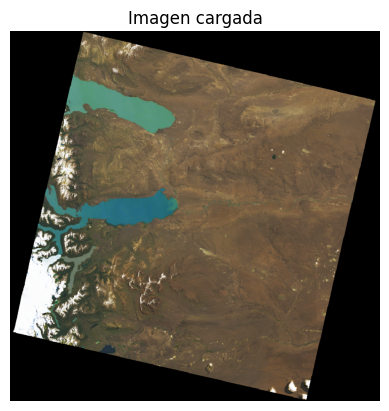

In [21]:
# a) Cargar una imagen de un archivo y desplegarla
def cargar_y_desplegar(ruta):
    img = cv2.imread(ruta)
    # Convertir de BGR a RGB para matplotlib
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title('Imagen cargada')
        plt.axis('off')
        plt.show()
    return img

img = cargar_y_desplegar(filename)

In [22]:
# b) Guardar una imagen a un archivo
def guardar_imagen(img, ruta_salida):
    cv2.imwrite(ruta_salida, img)
    print(f"Imagen guardada en: {ruta_salida}")

guardar_imagen(img, 'copia_imagen.jpg')

Imagen guardada en: copia_imagen.jpg


In [23]:
# c) Obtener el valor de un pixel en una imagen
def obtener_pixel(img, x, y):
    valor = img[y, x]
    print(f"Valor del pixel en ({x}, {y}): {valor}")
    return valor

pixel_val = obtener_pixel(img, 500, 500)

Valor del pixel en (500, 500): [ 73 104 126]


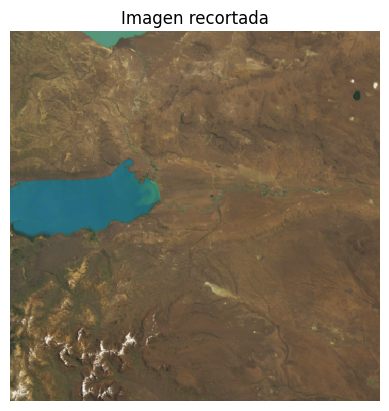

In [24]:
# d) Copiar una parte de la imagen en otra imagen nueva
def recortar_imagen(img, x_inicio, y_inicio, ancho, alto):
    recorte = img[y_inicio:y_inicio+alto, x_inicio:x_inicio+ancho].copy()

    img_rgb = cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title('Imagen recortada')
    plt.axis('off')
    plt.show()
    return recorte

# Tomamos un recorte central de la imagen
h, w = img.shape[:2]
recorte = recortar_imagen(img, w//2 - 250, h//2 - 250, 500, 500)

In [25]:
# e) Guardar la imagen cortada con otro nombre
guardar_imagen(recorte, 'imagen_recortada.jpg')

Imagen guardada en: imagen_recortada.jpg


## 3. Función de potencia $\gamma$

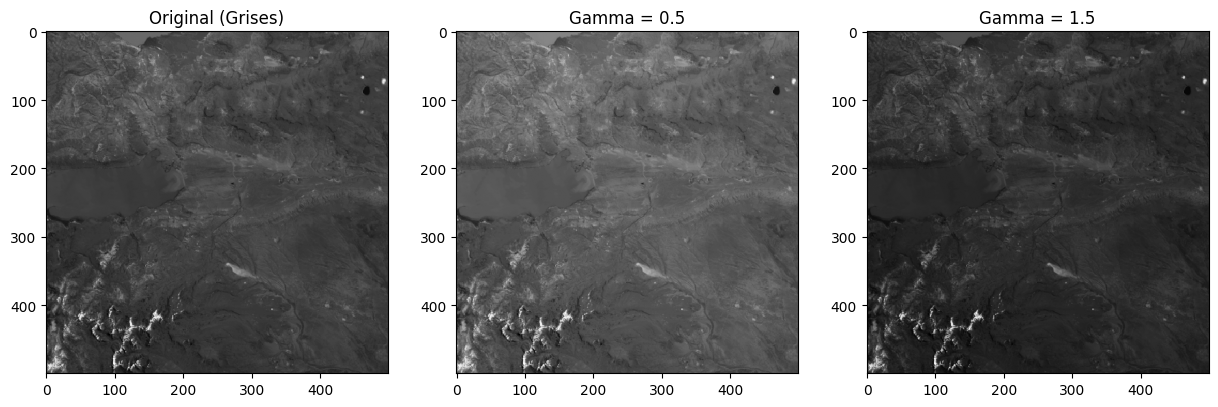

In [26]:
def aplicar_potencia(img, gamma):
    # Asegurar que sea en escala de grises
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img.copy()

    # Normalizar a [0, 1]
    img_norm = img_gray / 255.0

    # Aplicar transformación de potencia
    img_gamma = np.power(img_norm, gamma)

    # Escalar de vuelta a [0, 255]
    img_gamma = np.uint8(img_gamma * 255)

    return img_gamma

img_gamma_05 = aplicar_potencia(recorte, 0.5)
img_gamma_15 = aplicar_potencia(recorte, 1.5)

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2GRAY), cmap='gray'), plt.title('Original (Grises)')
plt.subplot(132), plt.imshow(img_gamma_05, cmap='gray'), plt.title('Gamma = 0.5')
plt.subplot(133), plt.imshow(img_gamma_15, cmap='gray'), plt.title('Gamma = 1.5')
plt.show()

## 4. Función de negativo

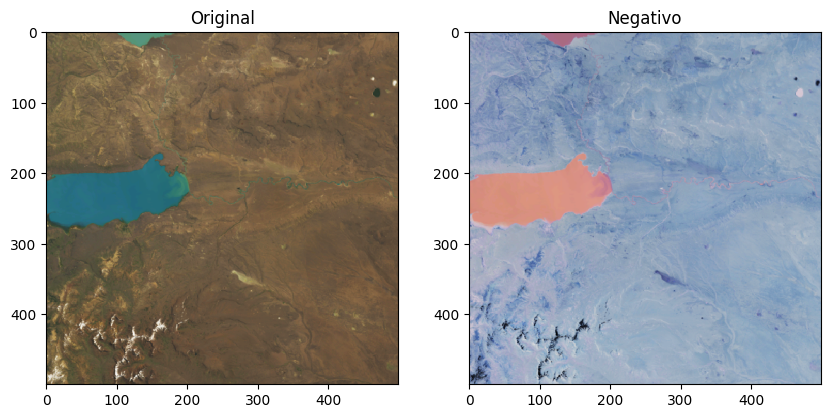

In [27]:
def aplicar_negativo(img):
    # Aplicar banda por banda
    b, g, r = cv2.split(img)
    b_neg = 255 - b
    g_neg = 255 - g
    r_neg = 255 - r

    img_neg = cv2.merge((b_neg, g_neg, r_neg))
    return img_neg

img_negativo = aplicar_negativo(recorte)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(122), plt.imshow(cv2.cvtColor(img_negativo, cv2.COLOR_BGR2RGB)), plt.title('Negativo')
plt.show()

## 5. Histograma de niveles de gris de cada banda

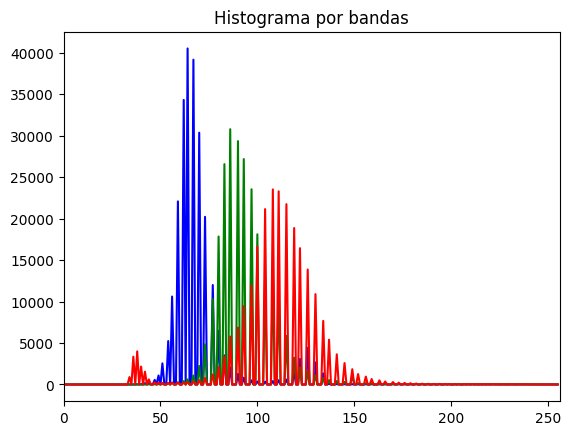

In [28]:
def mostrar_histogramas(img):
    color = ('b','g','r')
    for i, col in enumerate(color):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color = col)
        plt.xlim([0, 256])
    plt.title('Histograma por bandas')
    plt.show()

mostrar_histogramas(recorte)

## 6. Aplicar umbral a cada banda devolviendo binaria

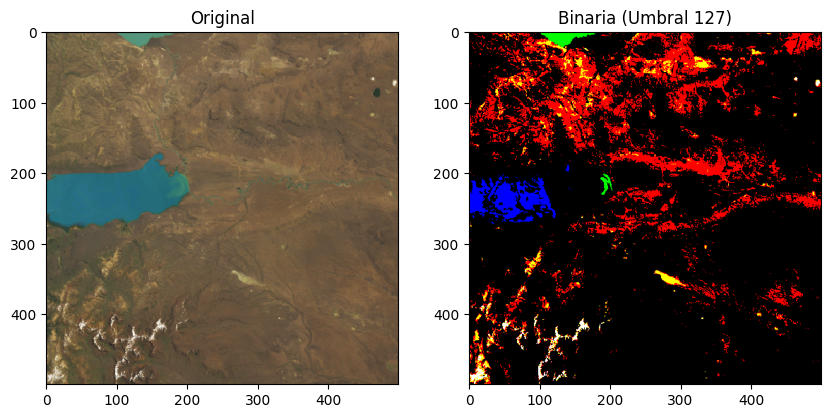

In [29]:
def aplicar_umbral_bandas(img, umbral):
    b, g, r = cv2.split(img)

    _, b_bin = cv2.threshold(b, umbral, 255, cv2.THRESH_BINARY)
    _, g_bin = cv2.threshold(g, umbral, 255, cv2.THRESH_BINARY)
    _, r_bin = cv2.threshold(r, umbral, 255, cv2.THRESH_BINARY)

    img_bin = cv2.merge((b_bin, g_bin, r_bin))
    return img_bin

img_umbral = aplicar_umbral_bandas(recorte, 127)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(122), plt.imshow(cv2.cvtColor(img_umbral, cv2.COLOR_BGR2RGB)), plt.title('Binaria (Umbral 127)')
plt.show()

## 7. Ecualización del histograma banda por banda

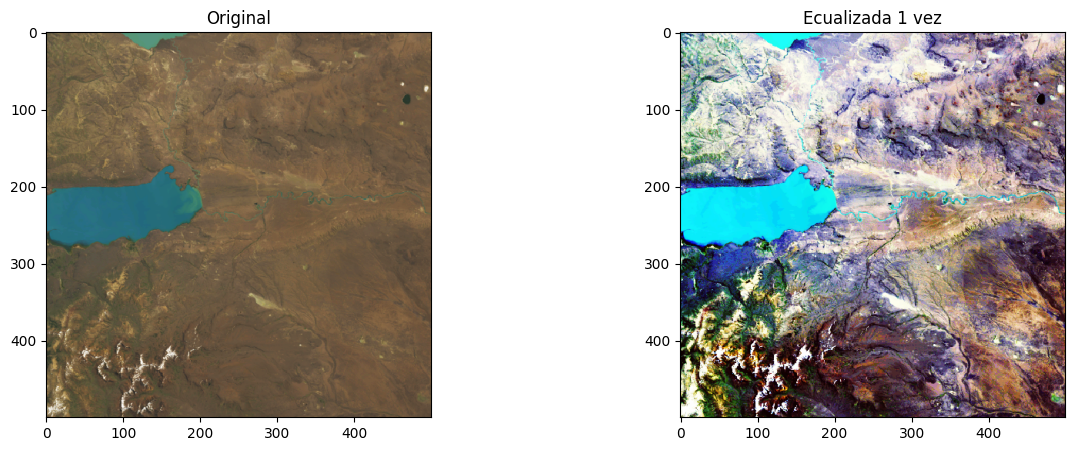

Histograma de imagen ecualizada:


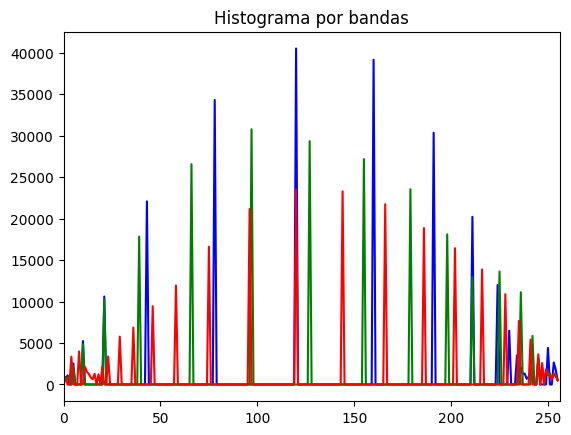

In [30]:
def ecualizar_histograma(img):
    b, g, r = cv2.split(img)

    b_eq = cv2.equalizeHist(b)
    g_eq = cv2.equalizeHist(g)
    r_eq = cv2.equalizeHist(r)

    img_eq = cv2.merge((b_eq, g_eq, r_eq))
    return img_eq

img_eq1 = ecualizar_histograma(recorte)

plt.figure(figsize=(15, 5))
plt.subplot(121), plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(122), plt.imshow(cv2.cvtColor(img_eq1, cv2.COLOR_BGR2RGB)), plt.title('Ecualizada 1 vez')
plt.show()

print("Histograma de imagen ecualizada:")
mostrar_histogramas(img_eq1)

## 8. Aplicar la ecualización por segunda vez a la misma imagen

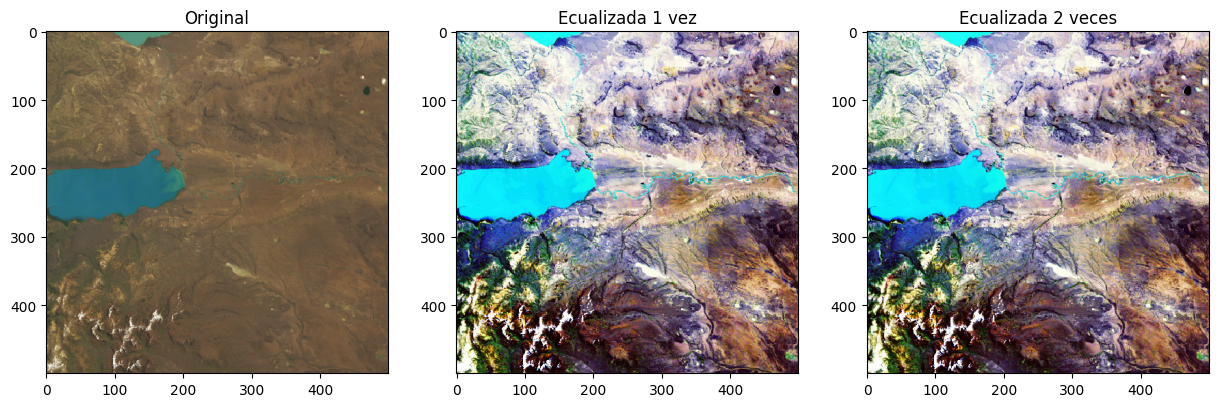

Histograma de imagen ecualizada 2 veces:


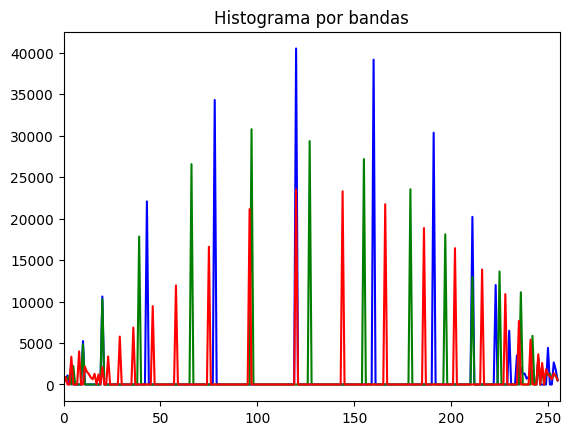

In [31]:
img_eq2 = ecualizar_histograma(img_eq1)

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(132), plt.imshow(cv2.cvtColor(img_eq1, cv2.COLOR_BGR2RGB)), plt.title('Ecualizada 1 vez')
plt.subplot(133), plt.imshow(cv2.cvtColor(img_eq2, cv2.COLOR_BGR2RGB)), plt.title('Ecualizada 2 veces')
plt.show()

print("Histograma de imagen ecualizada 2 veces:")
mostrar_histogramas(img_eq2)

**Explicación de lo sucedido:** Al aplicar la ecualización del histograma por segunda vez, la imagen no sufre cambios notables. Esto se debe a que la primera ecualización ya redistribuyó las intensidades de los píxeles para que el histograma sea lo más plano (uniforme) posible. Una vez que la distribución de probabilidad acumulada es aproximadamente lineal, una segunda ecualización vuelve a mapear los valores sobre sí mismos.

## 9. Agregar ruido a una imagen (Gaussiano y Exponencial)

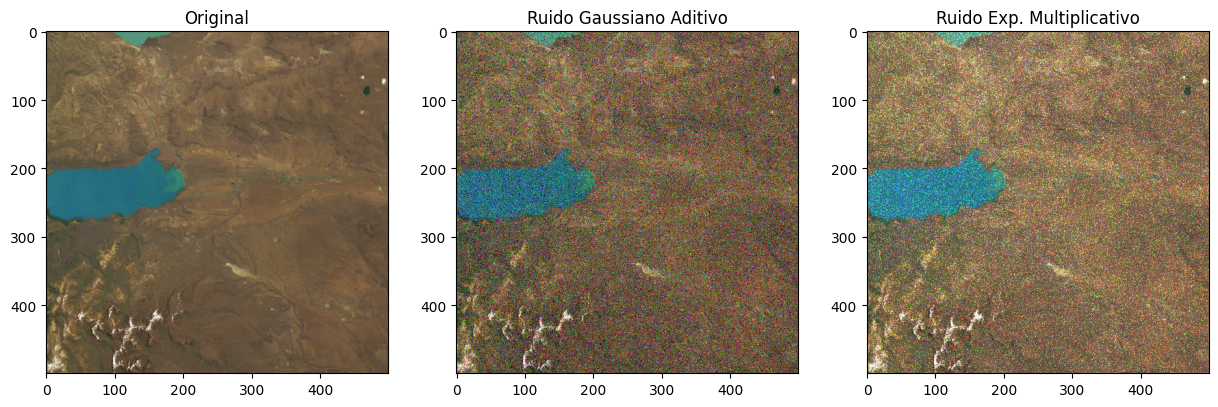

In [32]:
def agregar_ruido_gaussiano(img, porcentaje, media=0.0, varianza=0.01):
    img_norm = img / 255.0

    sigma = varianza**0.5
    gauss = np.random.normal(media, sigma, img_norm.shape)

    # Crear mascara basada en el porcentaje
    mask = np.random.rand(*img.shape[:2]) < (porcentaje / 100.0)
    mask = np.repeat(mask[:, :, np.newaxis], img.shape[2], axis=2) if len(img.shape) == 3 else mask

    ruidosa = img_norm.copy()
    ruidosa[mask] = ruidosa[mask] + gauss[mask]

    ruidosa = np.clip(ruidosa, 0, 1)
    ruidosa = np.uint8(ruidosa * 255)

    return ruidosa

def agregar_ruido_exponencial(img, porcentaje, escala=0.1):
    img_norm = img / 255.0

    # Ruido multiplicativo
    expo = np.random.exponential(escala, img_norm.shape)

    mask = np.random.rand(*img.shape[:2]) < (porcentaje / 100.0)
    mask = np.repeat(mask[:, :, np.newaxis], img.shape[2], axis=2) if len(img.shape) == 3 else mask

    ruidosa = img_norm.copy()
    ruidosa[mask] = ruidosa[mask] * (1 + expo[mask])

    ruidosa = np.clip(ruidosa, 0, 1)
    ruidosa = np.uint8(ruidosa * 255)

    return ruidosa

img_ruido_g = agregar_ruido_gaussiano(recorte, porcentaje=50, media=0, varianza=0.05)
img_ruido_e = agregar_ruido_exponencial(recorte, porcentaje=50, escala=0.5)

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(132), plt.imshow(cv2.cvtColor(img_ruido_g, cv2.COLOR_BGR2RGB)), plt.title('Ruido Gaussiano Aditivo')
plt.subplot(133), plt.imshow(cv2.cvtColor(img_ruido_e, cv2.COLOR_BGR2RGB)), plt.title('Ruido Exp. Multiplicativo')
plt.show()

## 10. Generador de ruido Sal y Pimienta

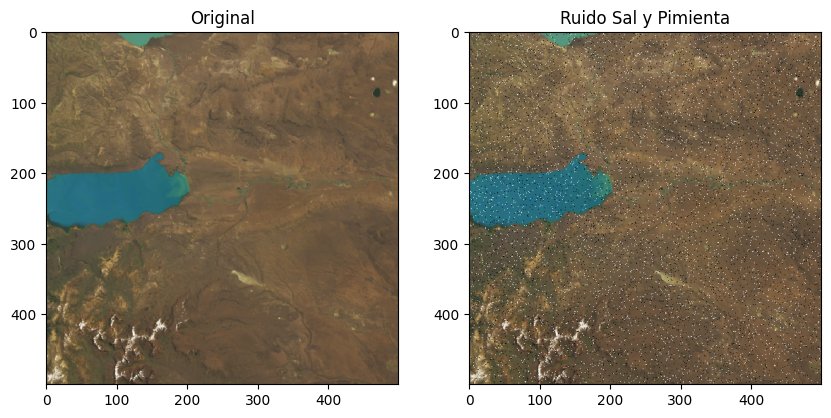

In [33]:
def agregar_ruido_sal_pimienta(img, porcentaje_sal, porcentaje_pimienta):
    ruidosa = img.copy()
    row, col = img.shape[:2]

    # Sal (Pixels blancos)
    num_sal = np.ceil((porcentaje_sal / 100.0) * img.size / (img.shape[2] if len(img.shape)==3 else 1))
    coords_sal = [np.random.randint(0, i - 1, int(num_sal)) for i in img.shape[:2]]
    ruidosa[tuple(coords_sal)] = 255

    # Pimienta (Pixels negros)
    num_pim = np.ceil((porcentaje_pimienta / 100.0) * img.size / (img.shape[2] if len(img.shape)==3 else 1))
    coords_pim = [np.random.randint(0, i - 1, int(num_pim)) for i in img.shape[:2]]
    ruidosa[tuple(coords_pim)] = 0

    return ruidosa

img_ruido_sp = agregar_ruido_sal_pimienta(recorte, porcentaje_sal=2, porcentaje_pimienta=2)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(122), plt.imshow(cv2.cvtColor(img_ruido_sp, cv2.COLOR_BGR2RGB)), plt.title('Ruido Sal y Pimienta')
plt.show()

## 11. Calcular índices NDVI, NDWI y SVI

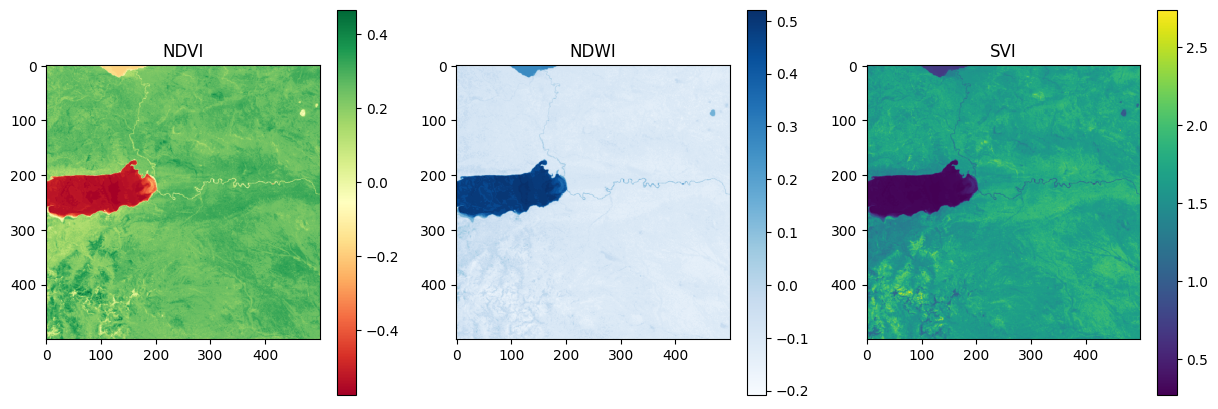

In [34]:
# Simularemos las bandas a partir de canales de nuestra imagen RGB para mostrar la implementación.

def calcular_indices(img_multiespectral):
    R = img_multiespectral[:,:,0].astype(float)
    G = img_multiespectral[:,:,1].astype(float)
    NIR = img_multiespectral[:,:,2].astype(float) # Simulado con el canal azul para el ejemplo

    epsilon = 1e-8 # Para prevenir división por cero

    # NDVI (Normalized Difference Vegetation Index) = (NIR - Red) / (NIR + Red)
    ndvi = (NIR - R) / (NIR + R + epsilon)

    # NDWI (Normalized Difference Water Index) = (Green - NIR) / (Green + NIR)
    ndwi = (G - NIR) / (G + NIR + epsilon)

    # SVI (Simple Vegetation Index) = NIR / Red
    svi = NIR / (R + epsilon)

    return ndvi, ndwi, svi

ndvi, ndwi, svi = calcular_indices(recorte)

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(ndvi, cmap='RdYlGn'), plt.title('NDVI'), plt.colorbar()
plt.subplot(132), plt.imshow(ndwi, cmap='Blues'), plt.title('NDWI'), plt.colorbar()
plt.subplot(133), plt.imshow(svi, cmap='viridis'), plt.title('SVI'), plt.colorbar()
plt.show()

## 12. Preguntas Teóricas

**a) Dado un pixel $(x, y)$, definir la 8-vecindad del pixel en función de sus coordenadas. ¿Por qué es importante la vecindad?**

La 8-vecindad de un píxel de coordenadas $(x, y)$ (denotada como $N_8(p)$) está formada por los 8 píxeles adyacentes a él, tanto en dirección horizontal, vertical, como diagonal. Sus coordenadas son:
- $(x-1, y-1), (x, y-1), (x+1, y-1)$
- $(x-1, y), \text{el píxel central }(x, y), (x+1, y)$
- $(x-1, y+1), (x, y+1), (x+1, y+1)$

Es importante porque muchos algoritmos de procesamiento espacial (filtros, detección de bordes, operaciones morfológicas) calculan el nuevo valor de un píxel basándose en los valores de sus vecinos, aprovechando la correlación espacial que existe en las imágenes.

**b) Dé la definición de histograma. ¿Para qué sirve estudiar el histograma de una imagen?**

Un histograma de una imagen digital es una representación gráfica de la distribución de frecuencias relativas o absolutas de los niveles de intensidad (o colores) presentes en la imagen. Muestra la cantidad de píxeles que poseen cada valor posible (ej. de 0 a 255).
Sirve para estudiar las características globales de contraste y brillo de una imagen. Permite identificar de manera rápida si una imagen es demasiado oscura, muy brillante o tiene un contraste deficiente, y permite tomar decisiones para aplicar mejoras, como ecualización o selección de umbrales para binarización.

**c) ¿Qué es una banda de una imagen? ¿Cuántas bandas tiene una imagen satelital óptica?**

Una banda (o canal) de una imagen es una matriz bidimensional de valores (píxeles) que representa la intensidad de la luz reflejada o emitida en un rango específico del espectro electromagnético (como rojo, verde, azul, infrarrojo).
La cantidad de bandas depende del sensor:
- **Pancromática**: 1 banda (escala de grises).
- **RGB**: 3 bandas.
- **Multiespectral (ej. Landsat 8)**: 11 bandas.
- **Hiperespectral**: Puede llegar a tener decenas o cientos de bandas estrechas.